In [1]:
%load_ext autoreload
%autoreload 2

In [115]:
import pandas as pd
import sys
import warnings
sys.path.append("A2")
sys.path.append("preprocessing")
import regression_tree as rt
import random_forest as rf
import prediction_evaluation as eval
import grid_search
import parameter_eval
import preprocessing_food_wastage as pre_food_wastage
import preprocessing_college_ranking as pre_college_ranking

pd.set_option("display.max_colwidth", None)

Dataset Food Wastage
The full dataframe consists of 1782 rows, and 11 attributes
Rows containing NA values before preprocessing: 0


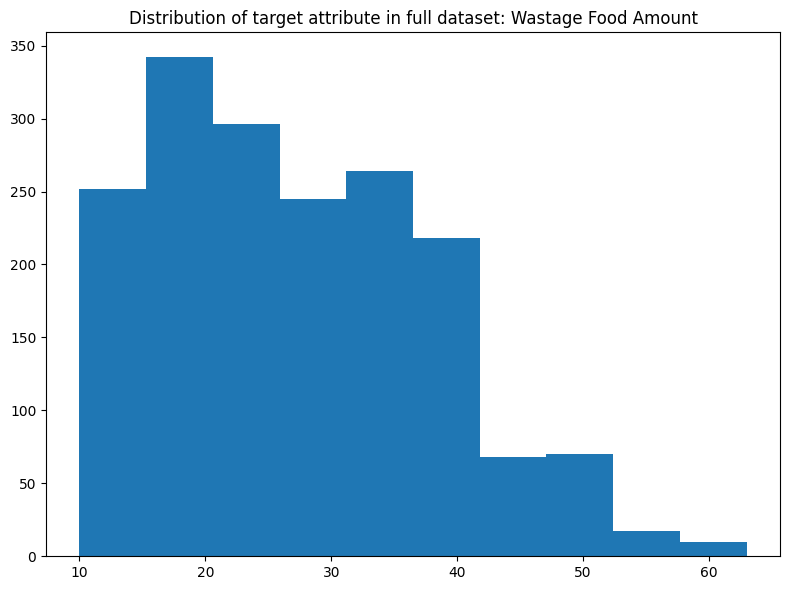

The train dataframe consists of 1188 rows, and 11 attributes


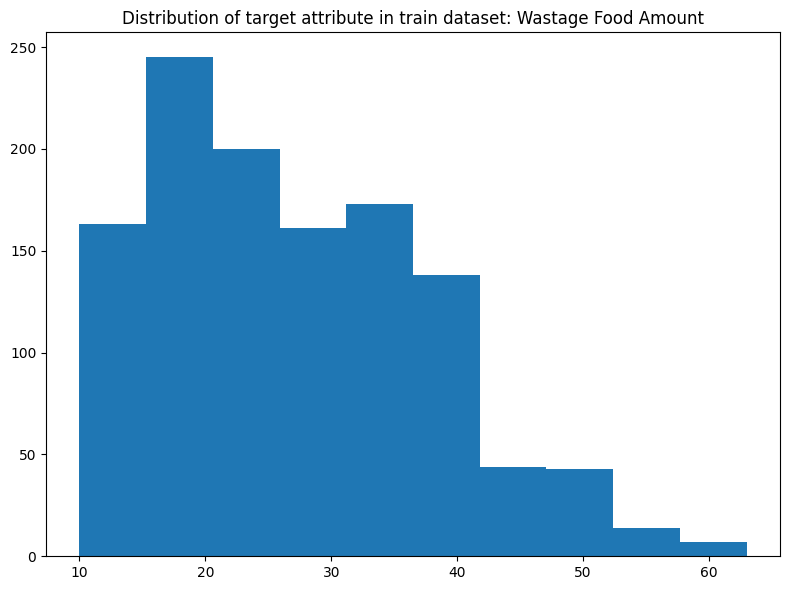

The test dataframe consists of 594 rows, and 11 attributes


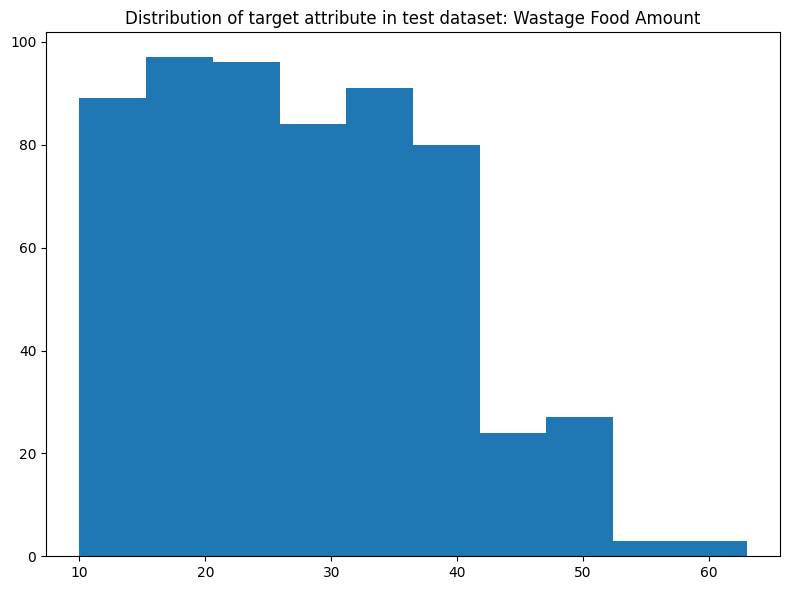

Dataset University Ranking
The full dataframe consists of 167 rows, and 41 attributes
Rows containing NA values before preprocessing: 160


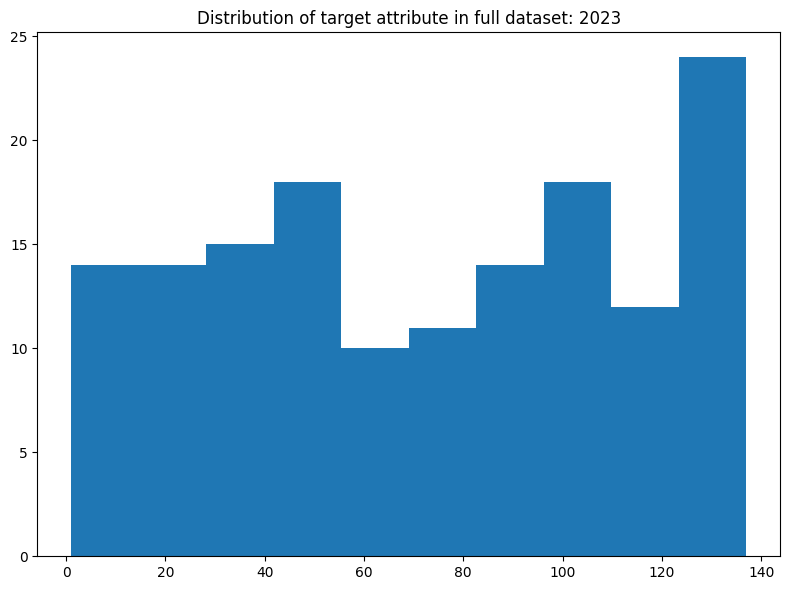

The train dataframe consists of 111 rows, and 41 attributes


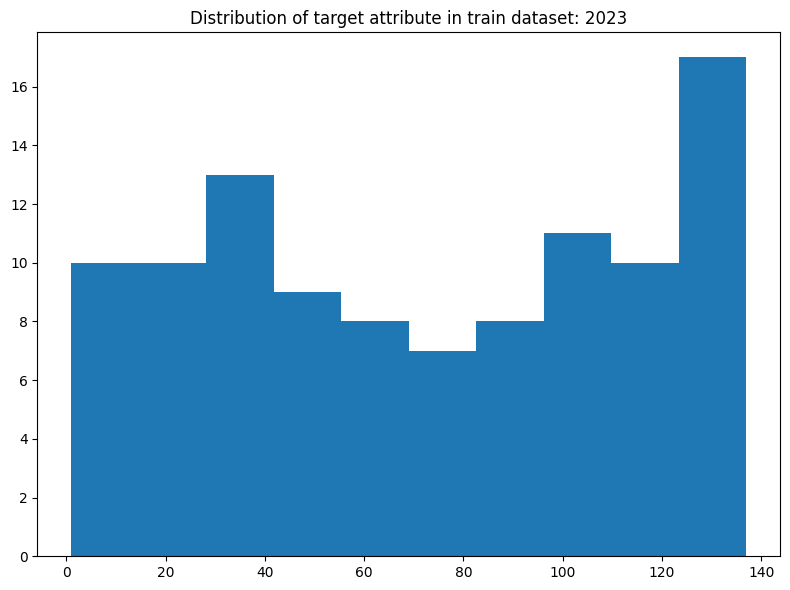

The test dataframe consists of 56 rows, and 41 attributes


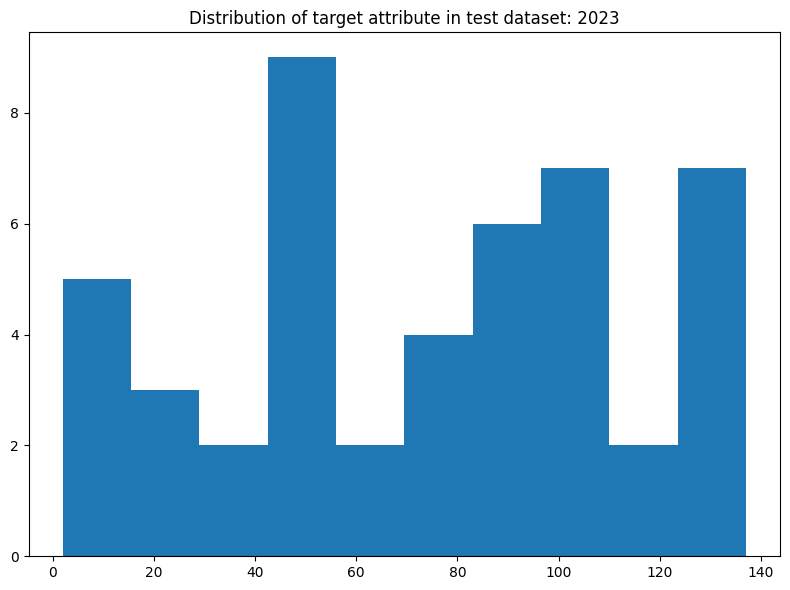

In [31]:
warnings.filterwarnings('ignore', category=FutureWarning)

food_waste_df_train, food_waste_df_test = pre_food_wastage.preprocessing_food_wastage()
college_rank_df_train, college_rank_df_test = pre_college_ranking.preprocessing_college_ranking()

In [ ]:
param_grid = {
    'min_samples_split': range(5,7,1),
    'max_depth': range(1,3,1),
    'split_criterion': ['sse', 'mae', 'mse']
}


param_grid_scikit = {
    'min_samples_split': range(5,7,1),
    'max_depth': range(1,3,1),
    'criterion': ['squared_error']
}


param_grid_rf = {
    'min_samples_split': range(5,7,1),
    'max_depth': range(1,3,1),
    'split_criterion': ['sse', 'mae', 'mse'],
    'no_of_estimators': range(1,3,2),
    'max_features_criterion': ['sqrt']
}


In [85]:
best_tree_food_waste, train_results_food_waste = grid_search.grid_search_cv(food_waste_df_train, "wastage_food_amount", rt.regression_tree, rt.predict_from_tree, param_grid)
train_results_food_waste.loc[:5,]

Running combo: 1 out of: 4
Running combo: 2 out of: 4
Running combo: 3 out of: 4
Running combo: 4 out of: 4


,runtime,mean_score,Parameters
0,545.050319,5.544798,"{'min_samples_split': 5, 'max_depth': 2, 'split_criterion': 'sse'}"
1,481.702526,5.552888,"{'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'sse'}"
2,211.940090,6.736227,"{'min_samples_split': 6, 'max_depth': 1, 'split_criterion': 'sse'}"
3,407.379519,6.738510,"{'min_samples_split': 5, 'max_depth': 1, 'split_criterion': 'sse'}"


In [ ]:
food_waste_predictions_reg_tree = rt.predict_from_tree(best_tree_food_waste, food_waste_df_test)
food_waste_rmse_reg_tree = eval.rmse(food_waste_df_test["wastage_food_amount"], food_waste_predictions_reg_tree)
print(f"RMSE score on test set: {food_waste_rmse_reg_tree}")


RMSE score on test set: 5.576393396194763


In [ ]:
sci_kit_results_food_waste, best_tree_scikit_food_waste = grid_search.grid_search_scikit(food_waste_df_train, "wastage_food_amount", param_grid_scikit)
sci_kit_results_food_waste.loc[:5,]

Fitting 5 folds for each of 2 candidates, totalling 10 fits
DecisionTreeRegressor(max_depth=2, min_samples_split=5, random_state=1)
Time(s):  0.10250949999317527


,runtime,mean_test_score,params
0,0.102509,5.555888,"{'criterion': 'squared_error', 'max_depth': 2,..."
1,0.102509,5.555888,"{'criterion': 'squared_error', 'max_depth': 2,..."


In [ ]:
food_waste_predictions_reg_tree_scikit = best_tree_scikit_food_waste.predict(food_waste_df_test.loc[:, food_waste_df_test.columns != "wastage_food_amount"])
food_waste_rmse_reg_tree_scikit = eval.rmse(food_waste_df_test["wastage_food_amount"], food_waste_predictions_reg_tree_scikit)
print(f"Food waste RMSE score on test set: {food_waste_rmse_reg_tree}")
print(f"Food waste RMSE score on test set using Scikit implementation: {food_waste_rmse_reg_tree_scikit}")

RMSE score on test set: 5.576393396194763
RMSE score on test set using Scikit implementation: 5.576393396194763


In [125]:
best_tree_college_rank, train_results_college_rank = grid_search.grid_search_cv(college_rank_df_train, "2023", rt.regression_tree, rt.predict_from_tree, param_grid)
train_results_college_rank

Running combo: 1 out of: 12
Running combo: 2 out of: 12
Running combo: 3 out of: 12
Running combo: 4 out of: 12
Running combo: 5 out of: 12
Running combo: 6 out of: 12
Running combo: 7 out of: 12
Running combo: 8 out of: 12
Running combo: 9 out of: 12
Running combo: 10 out of: 12
Running combo: 11 out of: 12
Running combo: 12 out of: 12


,runtime,mean_rmse,mean_mae,Parameters
0,81.969833,13.413941,11.236788,"{'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'sse'}"
1,27.501283,13.754770,11.661473,"{'min_samples_split': 5, 'max_depth': 2, 'split_criterion': 'sse'}"
2,29.793525,14.678925,12.128955,"{'min_samples_split': 5, 'max_depth': 2, 'split_criterion': 'mse'}"
3,30.461740,14.708236,12.413940,"{'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'mse'}"
4,21.855026,22.511889,19.245590,"{'min_samples_split': 6, 'max_depth': 1, 'split_criterion': 'sse'}"
5,19.675964,23.394559,19.920313,"{'min_samples_split': 5, 'max_depth': 1, 'split_criterion': 'sse'}"
6,55.800786,24.496695,20.620875,"{'min_samples_split': 6, 'max_depth': 1, 'split_criterion': 'mse'}"
7,19.207622,24.502635,20.802377,"{'min_samples_split': 5, 'max_depth': 1, 'split_criterion': 'mse'}"
8,52.600287,25.017622,21.413749,"{'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'mae'}"
9,35.518510,26.678500,22.418598,"{'min_samples_split': 6, 'max_depth': 1, 'split_criterion': 'mae'}"


In [118]:
college_rank_predictions_reg_tree = rt.predict_from_tree(best_tree_college_rank, college_rank_df_test)
college_rank_rmse_reg_tree = eval.measure_predictions(college_rank_df_test["2023"], college_rank_predictions_reg_tree, "rmse")
print(f"College rank RMSE score on test set: {college_rank_rmse_reg_tree}")

College rank RMSE score on test set: 14.590553112495714


In [119]:
sci_kit_results_college_rank, best_tree_scikit_college_rank = grid_search.grid_search_scikit(college_rank_df_train, "2023", param_grid_scikit)
sci_kit_results_college_rank

Fitting 5 folds for each of 4 candidates, totalling 20 fits
DecisionTreeRegressor(max_depth=2, min_samples_split=5, random_state=1)
Time(s):  0.4114983999170363


,runtime,mean_test_score,params
0,0.411498,13.459922,"{'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 6}"
1,0.411498,13.459922,"{'criterion': 'squared_error', 'max_depth': 2, 'min_samples_split': 5}"
2,0.411498,23.536969,"{'criterion': 'squared_error', 'max_depth': 1, 'min_samples_split': 6}"
3,0.411498,23.536969,"{'criterion': 'squared_error', 'max_depth': 1, 'min_samples_split': 5}"


In [120]:
college_rank_predictions_reg_tree_scikit = best_tree_scikit_college_rank.predict(college_rank_df_test.loc[:, college_rank_df_test.columns != "2023"])
college_rank_rmse_reg_tree_scikit = eval.rmse(college_rank_df_test["2023"], college_rank_predictions_reg_tree_scikit)
print(f"College Rank RMSE score on test set: {college_rank_rmse_reg_tree}")
print(f"College Rank RMSE score on test set using Scikit implementation: {college_rank_rmse_reg_tree_scikit}")

College Rank RMSE score on test set: 14.590553112495714
College Rank RMSE score on test set using Scikit implementation: 12.443080616026744


In [124]:
best_forest, train_results_rf_food_waste = grid_search.grid_search_obb(food_waste_df_train, "wastage_food_amount", param_grid_rf)
train_results_rf_food_waste

Running combo: 1 out of: 4
Running combo: 2 out of: 4
Running combo: 3 out of: 4
Running combo: 4 out of: 4


,runtime,mean_score,Parameters
0,7.315889,6.715378,"{'min_samples_split': 5, 'max_depth': 1, 'split_criterion': 'sse', 'no_of_estimators': 1, 'max_features_criterion': 'sqrt'}"
1,13.275645,6.722932,"{'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'sse', 'no_of_estimators': 1, 'max_features_criterion': 'sqrt'}"
2,10.626559,6.985684,"{'min_samples_split': 5, 'max_depth': 2, 'split_criterion': 'sse', 'no_of_estimators': 1, 'max_features_criterion': 'sqrt'}"
3,7.523716,9.424530,"{'min_samples_split': 6, 'max_depth': 1, 'split_criterion': 'sse', 'no_of_estimators': 1, 'max_features_criterion': 'sqrt'}"


In [73]:
food_waste_predictions_random_forest = rf.predict_from_forest(food_waste_df_test, best_forest)
food_waste_rmse_random_forest = eval.measure_predictions(food_waste_df_test["wastage_food_amount"], food_waste_predictions_random_forest, "rmse")
print(f"RMSE score on test set: {food_waste_rmse_random_forest}")

RMSE score on test set: 6.24744624914428


      runtime  mean_score  \
0  545.050319    5.544798   
1  481.702526    5.552888   

                                                           Parameters  \
0  {'min_samples_split': 5, 'max_depth': 2, 'split_criterion': 'sse'}   
1  {'min_samples_split': 6, 'max_depth': 2, 'split_criterion': 'sse'}   

      Dataset  min_samples_split  max_depth split_criterion  
0  Food waste                  5          2             sse  
1  Food waste                  6          2             sse  


KeyError: 'mean_rmse'

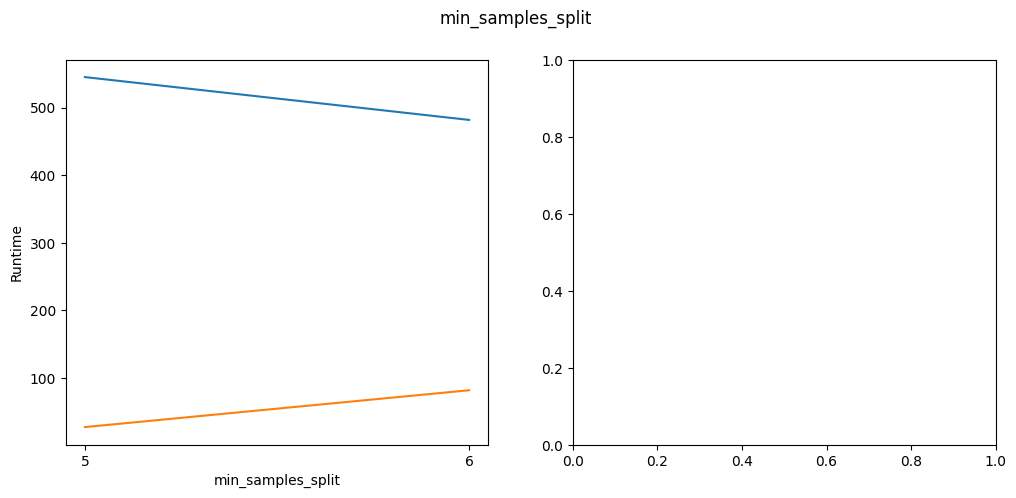

In [126]:
eval_param = {
    'min_samples_split': 5,
    'max_depth': 2,
    'split_criterion': 'sse'
}

parameter_eval.plot_parameter(train_results_food_waste, train_results_college_rank, param_grid, eval_param)

